# Stock Price Prediction

Predicting the closing price of a stock using an LSTM neural network. The example uses **MSFT** (Microsoft), but you can swap the ticker, re-run the notebook, and get predictions for any company.

## 1. Setup

Import libraries, confirm PyTorch version, and check GPU availability.

In [47]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

import torch.nn as nn        # neural network layers and loss functions
import torch.optim as optim  # optimisers (Adam, SGD, etc.)

from sklearn.preprocessing import StandardScaler     # normalise price data before training
from sklearn.metrics import root_mean_squared_error  # evaluate prediction accuracy in $ terms

print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.12.1+cu130
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


**CUDA** (Compute Unified Device Architecture) is NVIDIA's parallel computing platform. Instead of running operations one at a time on a CPU core, CUDA distributes work across thousands of GPU cores simultaneously — the RTX 3060 here has 3840 cores. For deep learning this means the matrix multiplications that dominate every forward and backward pass run orders of magnitude faster. PyTorch handles device placement automatically; we just assign `device` once and move tensors and model weights to it.

In [48]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [49]:
device

device(type='cuda')

## 2. Data Collection

Download historical daily price data using `yfinance`. Set `ticker` and `start_date` to pull data for any company.

In [50]:
ticker = 'MSFT'           # change to any valid ticker (e.g. 'AAPL', 'TSLA')
start_date = '2025-01-01'

df = yf.download(ticker, start=start_date)  # downloads daily OHLCV data from start_date to today

[*********************100%***********************]  1 of 1 completed


In [51]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2025-01-02,413.672607,421.074816,409.986357,420.541139,16896500
2025-01-03,418.386688,419.058709,414.621359,416.143282,16662900
2025-01-06,422.833954,429.228102,420.491744,422.982189,20573600
2025-01-07,417.418182,425.601107,415.866582,423.970458,18139100
2025-01-08,419.582520,421.964269,416.597936,418.495410,15054600


Each row is one trading day. The columns give us the standard OHLCV breakdown — **Open** and **Close** are the prices at market open and close, **High** and **Low** are the intraday extremes, and **Volume** is the number of shares traded. We'll focus on **Close** as the prediction target, since it's the most widely used reference price.

## 3. Visualisation

Each subplot covers one calendar quarter. MSFT opened 2025 around **$413–$422** and trended upward through Q1–Q2 2025 before pulling back. By mid-2026 the price sits in the **$380–$400** range, suggesting a gradual decline from the earlier highs. Splitting by quarter makes it easier to see whether the model struggles with a particular period or direction of trend.

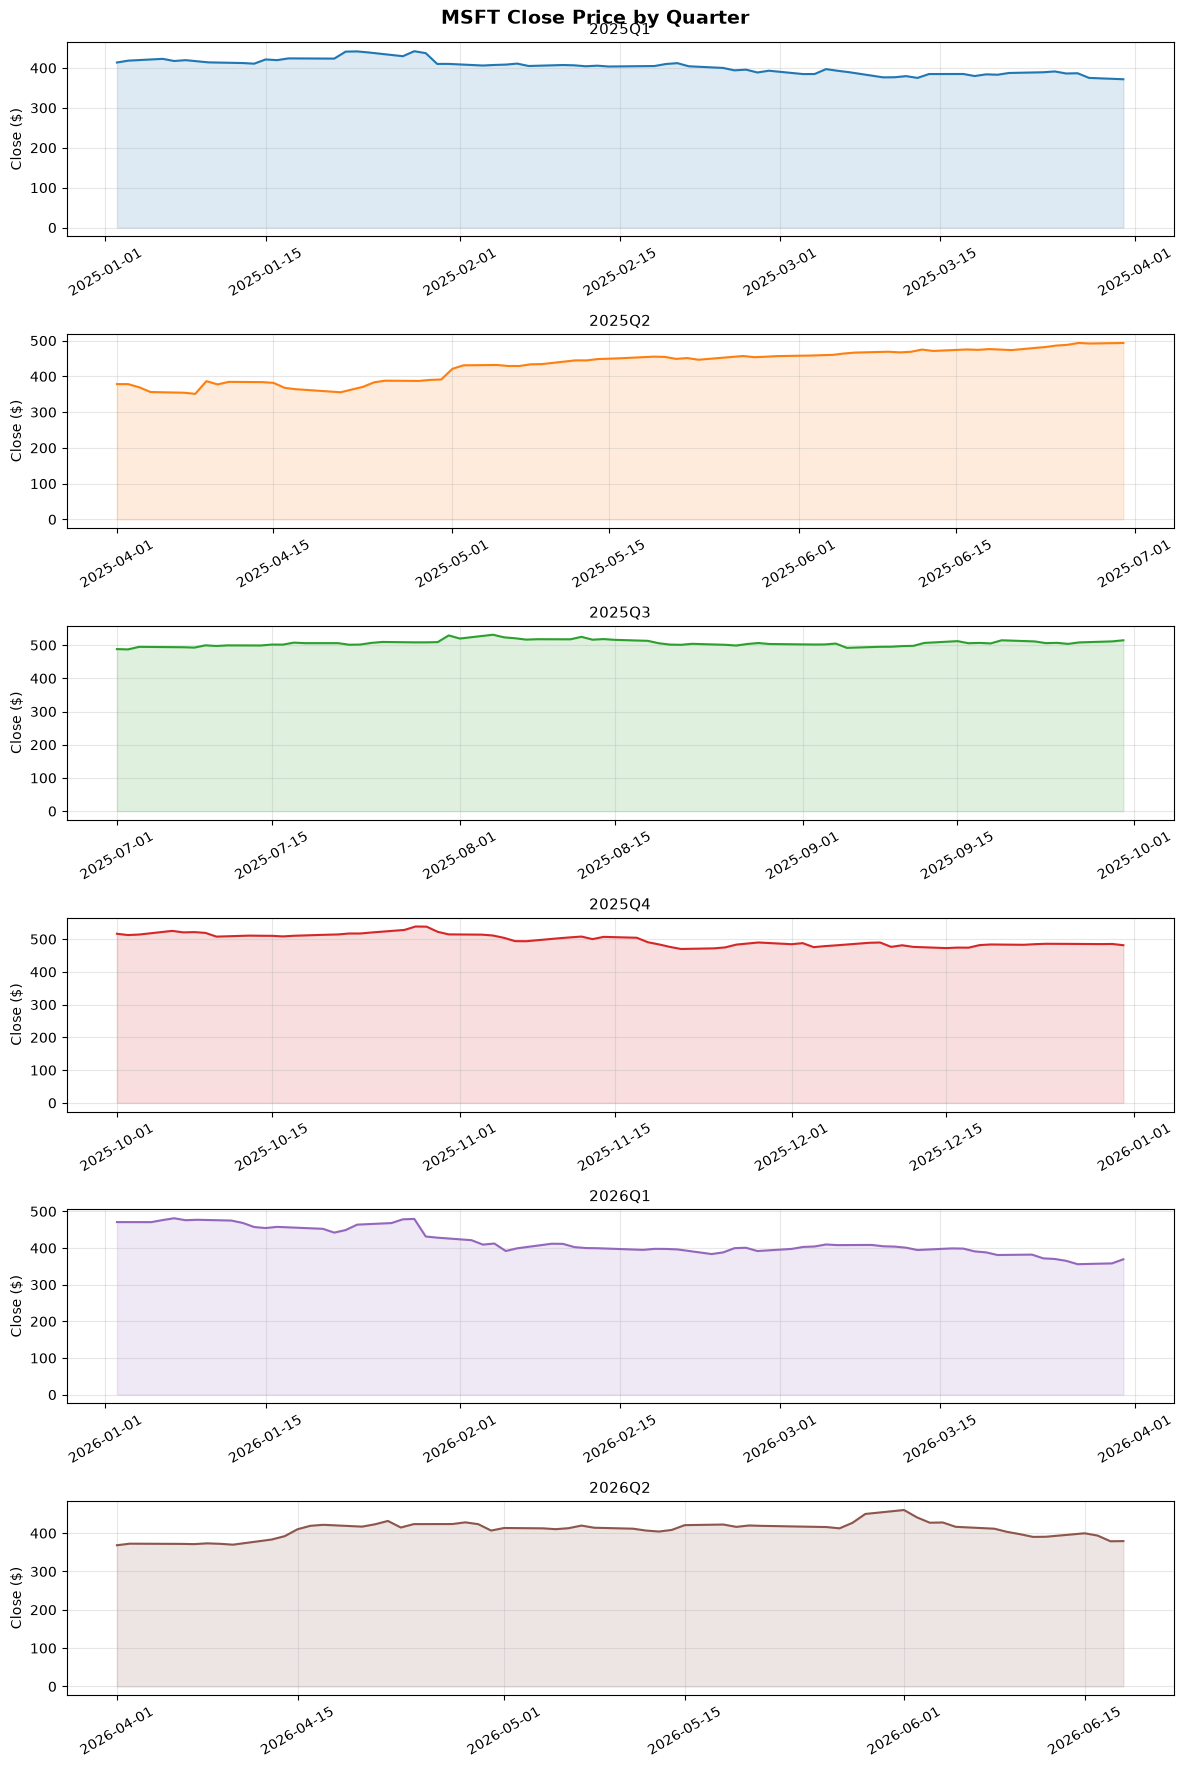

In [52]:
# extract Close prices and label each trading day with its calendar quarter
close = df['Close'][ticker].reset_index()
close.columns = ['Date', 'Close']
close['Quarter'] = pd.PeriodIndex(close['Date'], freq='Q')

quarters = close['Quarter'].unique()
n = len(quarters)

# one subplot per quarter
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

colors = plt.cm.tab10.colors
for i, (ax, q) in enumerate(zip(axes, quarters)):
    subset = close[close['Quarter'] == q]
    color = colors[i % len(colors)]
    ax.plot(subset['Date'], subset['Close'], color=color, linewidth=1.5)
    ax.fill_between(subset['Date'], subset['Close'], alpha=0.15, color=color)
    ax.set_title(str(q), fontsize=11)
    ax.set_ylabel('Close ($)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{ticker} Close Price by Quarter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'MSFT Close Price'}, xlabel='Date'>

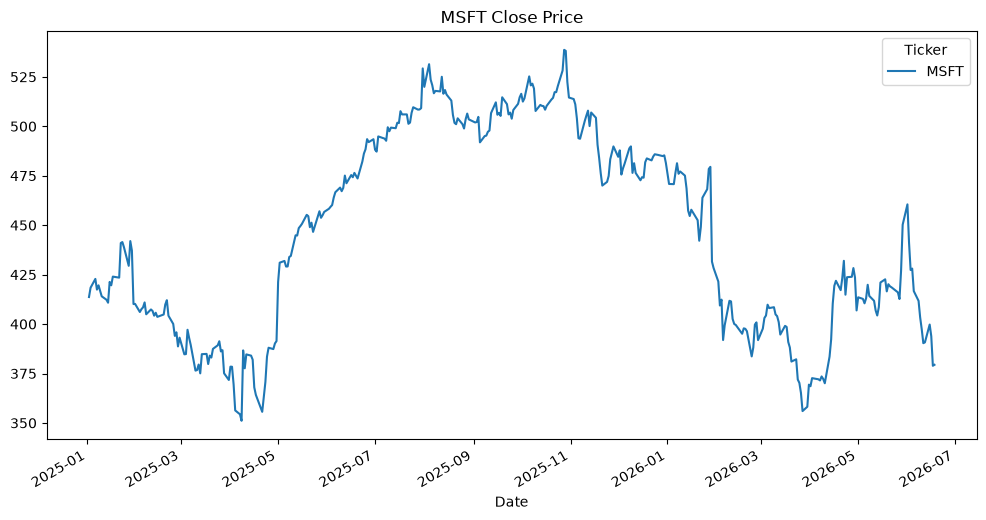

In [ ]:
df.Close.plot(figsize=(12, 6), title=f'{ticker} Close Price', grid=False)

## 4. Preprocessing

Two steps are required before training:

**Scaling** — `StandardScaler` transforms close prices to zero mean and unit variance. Neural networks train poorly on raw dollar values; normalised inputs keep gradients stable and make the loss comparable across different stocks.

**Sequence building** — `SEQ_LENGTH = 60` means the model receives 60 consecutive trading days (~3 months) and is asked to predict the price on day 61. A sliding window steps through the entire price history to generate as many training examples as possible.

The 80/20 split is done **chronologically** — shuffling time-series data would leak future prices into training.

In [53]:
scaler = StandardScaler()
close_prices  = df['Close'][ticker].values.reshape(-1, 1)
close_scaled  = scaler.fit_transform(close_prices)  # zero mean, unit variance

SEQ_LENGTH = 60  # trading days of history per prediction (~3 months)

def build_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])  # window of seq_len days
        y.append(data[i + seq_len])       # the very next day's price
    return np.array(X), np.array(y)

X, y = build_sequences(close_scaled, SEQ_LENGTH)
print(f"Input shape:  {X.shape}")   # (samples, seq_len, 1)
print(f"Target shape: {y.shape}")   # (samples, 1)

# chronological 80/20 split
split   = int(len(X) * 0.8)
X_train = torch.tensor(X[:split], dtype=torch.float32).to(device)
X_test  = torch.tensor(X[split:], dtype=torch.float32).to(device)
y_train = torch.tensor(y[:split], dtype=torch.float32).to(device)
y_test  = torch.tensor(y[split:], dtype=torch.float32).to(device)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

Input shape:  (306, 60, 1)
Target shape: (306, 1)
Train: 244 samples  |  Test: 62 samples


## 5. Model Architecture — LSTM

**LSTMs** (Long Short-Term Memory networks) are a type of recurrent neural network built for sequential data. Standard RNNs fail on long sequences because gradients vanish during backpropagation — the network forgets what it saw early on. LSTM cells fix this with three learnable **gates**:

- **Forget gate** — decides what to drop from the cell state
- **Input gate** — decides what new information to store
- **Output gate** — decides what to pass to the next timestep

For stock prices this matters: a 60-day context window requires the model to carry useful signal from day 1 all the way to day 60, which a plain RNN can't reliably do.

**Architecture:**
- 2 stacked LSTM layers with 64 hidden units each
- 20% dropout between layers (reduces overfitting on small datasets)
- 1 fully-connected output layer mapping the final hidden state to a single price prediction

In [54]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,    # one feature: the scaled close price
            hidden_size=hidden_size,  # 64 hidden units per LSTM cell
            num_layers=num_layers,    # 2 stacked LSTM layers
            batch_first=True,         # input shape: (batch, seq_len, features)
            dropout=0.2               # regularisation applied between layers
        )
        # maps final hidden state → single price prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # only the last timestep carries the full sequence summary

model = LSTMModel().to(device)
print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 6. Training

We train with `nn.MSELoss()`, which minimises the **mean squared error** between predicted and actual scaled prices. MSE is the standard loss for regression — it's differentiable everywhere and penalises large errors more than small ones, pushing the model to avoid big misses.

The reported metric is **RMSE** (root mean squared error): `RMSE = √MSE`. Taking the square root brings the error back to the same unit as the price (USD). An RMSE of $5 means predictions are off by roughly $5 on average — directly interpretable without any unit conversion.

In [55]:
criterion = nn.MSELoss()                            # minimise mean squared error during training
optimizer = optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 100

train_losses = []
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train)
    loss  = criterion(preds, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  |  MSE Loss: {loss.item():.6f}")

Epoch  10/100  |  MSE Loss: 0.779008
Epoch  20/100  |  MSE Loss: 0.415128
Epoch  30/100  |  MSE Loss: 0.130046
Epoch  40/100  |  MSE Loss: 0.101075
Epoch  50/100  |  MSE Loss: 0.090697
Epoch  60/100  |  MSE Loss: 0.075722
Epoch  70/100  |  MSE Loss: 0.065791
Epoch  80/100  |  MSE Loss: 0.058866
Epoch  90/100  |  MSE Loss: 0.054889
Epoch 100/100  |  MSE Loss: 0.054462


## 7. Evaluation

The model predicts on the held-out test set. Scaled predictions are inverse-transformed back to real dollar values using the same scaler fitted on training data, then plotted against actual close prices and summarised with RMSE.

Test RMSE: $15.18


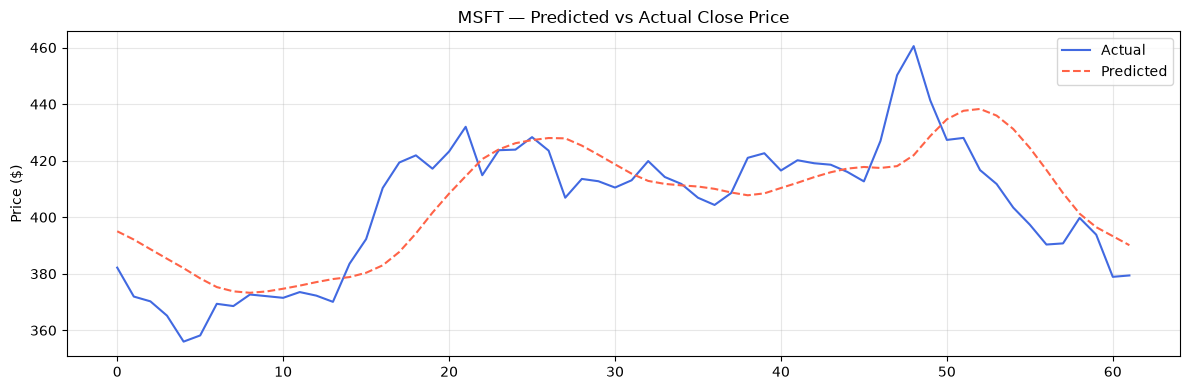

In [56]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test).cpu().numpy()

pred   = scaler.inverse_transform(pred_scaled)           # back to real USD values
actual = scaler.inverse_transform(y_test.cpu().numpy())

rmse = root_mean_squared_error(actual, pred)
print(f"Test RMSE: ${rmse:.2f}")

plt.figure(figsize=(12, 4))
plt.plot(actual, label='Actual',    color='royalblue')
plt.plot(pred,   label='Predicted', color='tomato', linestyle='--')
plt.title(f'{ticker} — Predicted vs Actual Close Price')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This model did not perform too well, the 60-day history was too much, and the dropout and over 60 hidden layers did not really help. In the upcoming sections, we reduced the number of hidden layers, and removed the dropout, and we used a double zeroes layer to help us out.

In [35]:
scaler = StandardScaler()

df.Close = scaler.fit_transform(df.Close)

df.Close

Ticker,MSFT
Date,
2025-01-02,-0.636382
2025-01-03,-0.542602
2025-01-06,-0.454131
2025-01-07,-0.561869
2025-01-08,-0.518813
...,...
2026-06-12,-1.092591
2026-06-15,-0.913151
2026-06-16,-1.031120


In [36]:
seq_length = 30 # number of days
data = []

for i in range(len(df.Close) - seq_length):
  data.append(df.Close[i:i+seq_length])

data = np.array(data)
data

array([[[-0.6363818 ],
        [-0.54260184],
        [-0.45413097],
        ...,
        [-0.82393928],
        [-0.79445   ],
        [-0.83593193]],

       [[-0.54260184],
        [-0.45413097],
        [-0.56186876],
        ...,
        [-0.79445   ],
        [-0.83593193],
        [-0.81214393]],

       [[-0.45413097],
        [-0.56186876],
        [-0.51881262],
        ...,
        [-0.83593193],
        [-0.81214393],
        [-0.71128762]],

       ...,

       [[-0.65521161],
        [-0.69967622],
        [-0.64846248],
        ...,
        [-1.10054802],
        [-1.09259076],
        [-0.91315142]],

       [[-0.69967622],
        [-0.64846248],
        [-0.51328073],
        ...,
        [-1.09259076],
        [-0.91315142],
        [-1.03112006]],

       [[-0.64846248],
        [-0.51328073],
        [-0.62543578],
        ...,
        [-0.91315142],
        [-1.03112006],
        [-1.32793006]]], shape=(336, 30, 1))

In [37]:
train_size = int(len(data) * 0.8)

X_train = torch.from_numpy(data[:train_size, :-1, :]).float().to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).float().to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).float().to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).float().to(device)

In [38]:
X_train

tensor([[[-0.6364],
         [-0.5426],
         [-0.4541],
         ...,
         [-0.7768],
         [-0.8239],
         [-0.7944]],

        [[-0.5426],
         [-0.4541],
         [-0.5619],
         ...,
         [-0.8239],
         [-0.7944],
         [-0.8359]],

        [[-0.4541],
         [-0.5619],
         [-0.5188],
         ...,
         [-0.7944],
         [-0.8359],
         [-0.8121]],

        ...,

        [[ 0.4483],
         [ 0.6523],
         [ 0.6730],
         ...,
         [-0.8224],
         [-0.7136],
         [-0.7477]],

        [[ 0.6523],
         [ 0.6730],
         [-0.2802],
         ...,
         [-0.7136],
         [-0.7477],
         [-0.7388]],

        [[ 0.6730],
         [-0.2802],
         [-0.3438],
         ...,
         [-0.7477],
         [-0.7388],
         [-0.8112]]], device='cuda:0')

In [39]:
y_train

tensor([[-0.8359],
        [-0.8121],
        [-0.7113],
        [-0.6681],
        [-0.8242],
        [-0.9071],
        [-1.0273],
        [-0.9912],
        [-1.1331],
        [-1.0452],
        [-1.2126],
        [-1.2103],
        [-0.9658],
        [-1.0472],
        [-1.1177],
        [-1.3767],
        [-1.3710],
        [-1.3155],
        [-1.4041],
        [-1.2113],
        [-1.2085],
        [-1.3105],
        [-1.2258],
        [-1.2451],
        [-1.1581],
        [-1.1222],
        [-1.0812],
        [-1.1835],
        [-1.1715],
        [-1.4035],
        [-1.4707],
        [-1.3368],
        [-1.3377],
        [-1.5156],
        [-1.7770],
        [-1.8160],
        [-1.8811],
        [-1.1732],
        [-1.3533],
        [-1.2134],
        [-1.2260],
        [-1.2670],
        [-1.5452],
        [-1.6206],
        [-1.7912],
        [-1.6395],
        [-1.4904],
        [-1.2361],
        [-1.1465],
        [-1.1600],
        [-1.1033],
        [-1.0793],
        [-0.

## 5. Model Architecture — LSTM

This model uses an **LSTM** (Long Short-Term Memory network), a recurrent neural network architecture designed for sequential data. Unlike a basic RNN, an LSTM can retain useful information across many timesteps using an internal **cell state** and a set of learnable gates.

This is useful for stock-price forecasting because each prediction is based on a sequence of previous prices. Instead of treating each day independently, the LSTM processes the input window step by step and learns temporal patterns such as recent trends, momentum, and longer-range dependencies.

Each LSTM cell uses three main gates:

* **Forget gate** — decides what previous information should be removed from the cell state
* **Input gate** — decides what new information should be added
* **Output gate** — decides what information should be passed forward as the hidden state

The model takes a sequence of stock-price values as input and returns a single predicted price. After the LSTM processes the full input window, only the hidden representation from the **final timestep** is passed into a fully connected layer to produce the final prediction.

**Architecture:**

* Input size: 1 feature per timestep, representing the stock price
* 2 stacked LSTM layers
* 32 hidden units per LSTM layer
* Final hidden state from the last timestep is used for prediction
* 1 fully connected output layer maps the hidden state to a single predicted price

In the forward pass, the model first initializes the hidden state `h0` and cell state `c0` as zero tensors. These are created with the correct number of layers, batch size, and hidden size, then moved to the same device as the input data.

The input sequence is passed through the LSTM, which returns an output for every timestep. Since the task is to predict one final value, the model selects only the output from the final timestep using:

This final timestep representation summarizes the information learned from the full input sequence. It is then passed through a linear layer to produce the final stock-price prediction.


In [40]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

In [41]:
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
num_epochs = 200

for epoch in range(num_epochs):
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch [20/200], Loss: 0.0613
Epoch [40/200], Loss: 0.0373
Epoch [60/200], Loss: 0.0308
Epoch [80/200], Loss: 0.0264
Epoch [100/200], Loss: 0.0224
Epoch [120/200], Loss: 0.0197
Epoch [140/200], Loss: 0.0191
Epoch [160/200], Loss: 0.0189
Epoch [180/200], Loss: 0.0187
Epoch [200/200], Loss: 0.0185


In [42]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.cpu().detach().numpy())
y_train = scaler.inverse_transform(y_train.cpu().detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.cpu().detach().numpy())
y_test = scaler.inverse_transform(y_test.cpu().detach().numpy())


In [43]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [44]:
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

Train RMSE: 6.84
Test RMSE: 8.21


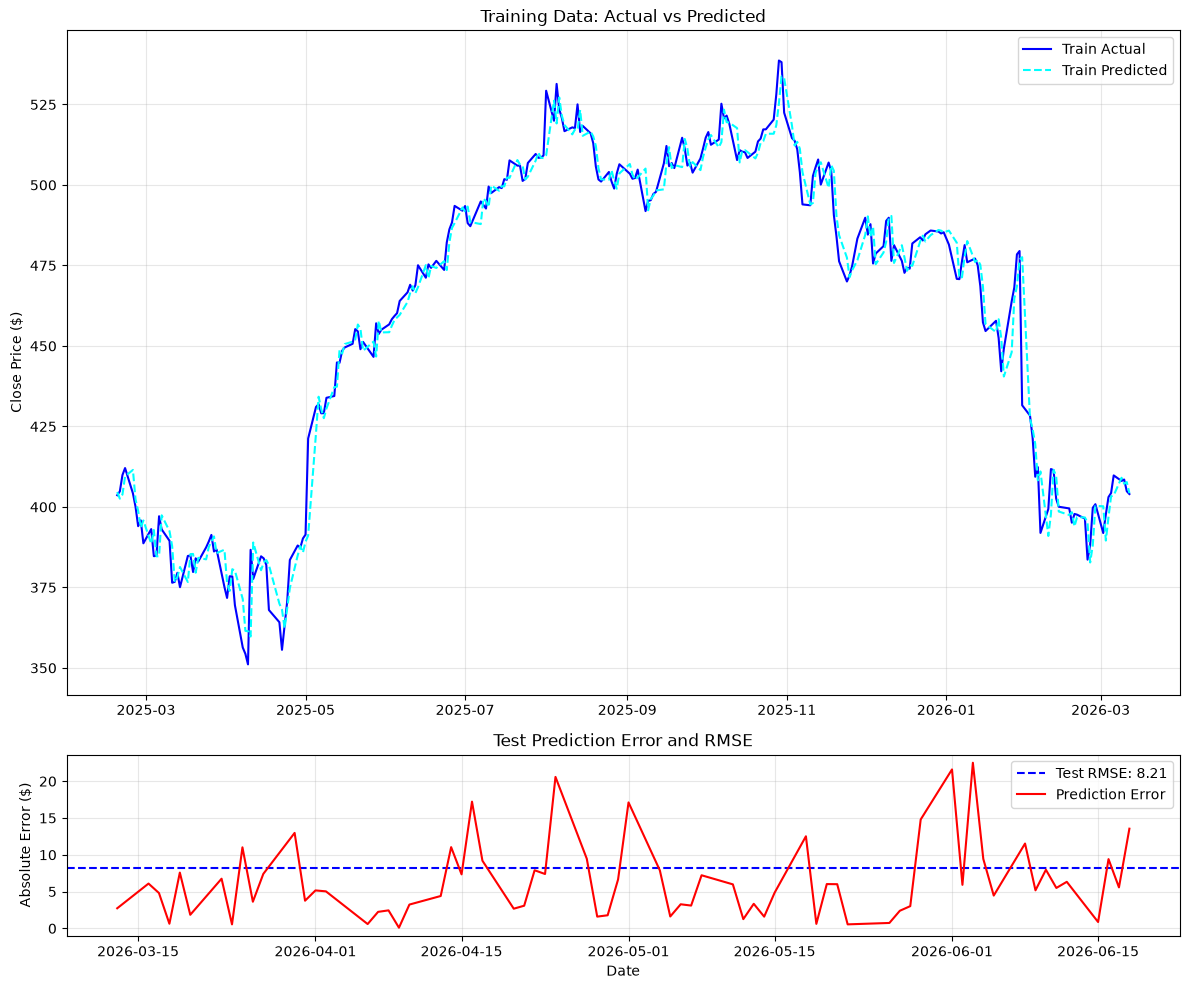

In [45]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.index[seq_length:train_size+seq_length], y_train[:, 0], label='Train Actual', color='blue')
ax1.plot(df.index[seq_length:train_size+seq_length], y_train_pred[:, 0], label='Train Predicted', color='cyan', linestyle='--')
ax1.set_title('Training Data: Actual vs Predicted', fontsize=12)
ax1.set_ylabel('Close Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# test actual vs test predicted with rmse in the middle
ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label=f'Test RMSE: {test_rmse:.2f}')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), label='Prediction Error', color='red')
ax2.legend()
plt.title('Test Prediction Error and RMSE', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Absolute Error ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
# plot according to rmse